### aim: 

### date: 

In [8]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')


In [9]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [10]:
import numpy as np
from cmocean import cm
import cartopy as cp
import cartopy.crs as ccrs
import netCDF4 as nc
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
import cartopy.feature as cfeature
from importlib import reload
import matplotlib.path as mpath
import glob
import pickle
import pandas as pd
import seawater
import time
plt.rcParams.update({'font.size': 13})
font = {'family' : 'normal',
'weight' : 'normal',
'size'   : 13}
plt.rcParams['text.usetex'] = True
plt.rc('font', **font)

import sys
sys.path.append('/gpfs/home/mep22dku/scratch/SOZONE/UTILS')
import snippets as sp
reload(sp)

import helper_fxns as hf

In [11]:
dir(sp)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'sniplist',
 'tdf',
 'tfig',
 'tmask',
 'tmetro',
 'tmodi',
 'txr',
 'tylist']

In [12]:
sp.tmetro()

metro = ['#6db8ff', '#de4231','#f3c108','#02954f','#01529b']
#skyblue, red, yellow, green, blue
20 named cols by sasha trubetskoy:
tcol = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#ffffff', '#000000']'


# dictionary of runs (4 ARIA runs + 2 GCB runs for comparison)

In [15]:
#metro = ['#6db8ff', '#de4231','#f3c108','#02954f','#01529b']
#skyblue, red, yellow, green, blue

mods = ['TOM12_TJ_A5BB','TOM12_TJ_C5BB', 'TOM12_TJ_A5H3', 'TOM12_TJ_A5H6',\
       'TOM12_TJ_25A0','TOM12_TJ_25C0']

lw = 1.5 
models = {
    
    "TOM12_TJ_25A0": {
        "linestyle": ":", "linewidth": lw,"description": "GCB 2025 A (sal. rest)","color": "#de4231"},
    "TOM12_TJ_25C0": {
        "linestyle": ":", "linewidth": lw,"description": "GCB 2025 C (sal. rest)","color": "#f3c108"},
    
    
    "TOM12_TJ_A5BB": {
        "linestyle": "-", "linewidth": lw,"description": "TiMBER A (no SR, flxcorr 5x)","color": "#de4231"},
    "TOM12_TJ_C5BB": {
        "linestyle": "-", "linewidth": lw,"description": "TiMBER C (no SR, flxcorr 5x)","color": "#f3c108"},
    
    "TOM12_TJ_A5H3": {
        "linestyle": "-", "linewidth": lw,"description": "TiMBER A  u03_hos","color": "#02954f"},
    "TOM12_TJ_A5H6": {
        "linestyle": "-", "linewidth": lw,"description": "TiMBER A  u06_hos","color": "#6db8ff"},

}


Text(0.5, 0.98, 'AMOC for TimBER runs (with GCB 2025 for comparison)')

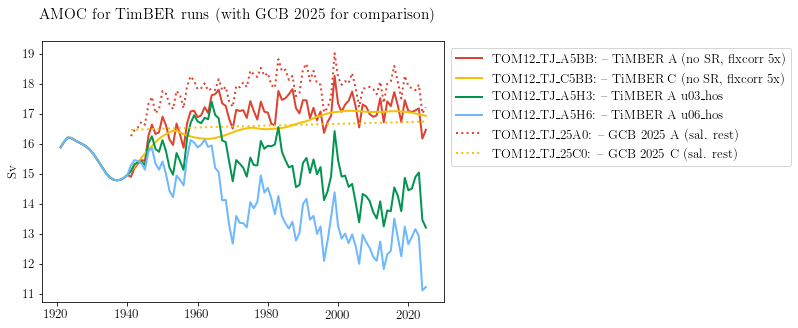

In [22]:

mods = ['TOM12_TJ_A5BB','TOM12_TJ_C5BB', 'TOM12_TJ_A5H3', 'TOM12_TJ_A5H6',]
mods2 = ['TOM12_TJ_25A0','TOM12_TJ_25C0']

fact = 0.6
fig, axs = plt.subplots(1,1, figsize=(12*fact, 8*fact), facecolor='w', edgecolor='k')
# axs = axs.ravel()

for m in mods:
    
    ds = xr.open_mfdataset(hf.make_yearlist_AMOC(1920, 2024, m))
    yearly_AMOC = ds['AMOC'].resample(time_counter='1Y').mean()
    
    desc = models[m]['description']
    axs.plot(yearly_AMOC.time_counter, yearly_AMOC, lw = 2, \
             linestyle = models[m]['linestyle'], label = f'{m}: -- {desc}',\
             color = models[m]['color'])
    
for m in mods2:
    
    ds = xr.open_mfdataset(hf.make_yearlist_AMOC(1940, 2024, m))
    yearly_AMOC = ds['AMOC'].resample(time_counter='1Y').mean()
    
    desc = models[m]['description']
    axs.plot(yearly_AMOC.time_counter, yearly_AMOC, lw = 2, \
             linestyle = models[m]['linestyle'], label = f'{m}: -- {desc}',\
             color = models[m]['color'])
    

axs.legend(bbox_to_anchor = [1,1])
axs.set_ylabel('Sv')
#axs[1].legend(bbox_to_anchor = [1,1])

plt.suptitle('AMOC for TimBER runs (with GCB 2025 for comparison)')